# **Assignment 2**

**!! # OpenCV reads as BGR, matplotlib expects RGB**, if a picture looks weird, this is the reason

Standardization at the beginning of the network (Rescaling layer)
https://keras.io/examples/vision/image_classification_from_scratch/

Imports:

In [ ]:
import glob
import cv2
import json

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Loading the data:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with open('/content/drive/MyDrive/Colab Notebooks/minifigs.json', 'r') as file:
    labels = json.load(file)

labels = pd.DataFrame(labels)
print(labels.head())

   id                                               name  \
0   1  LEGOLAND - Black Torso, Black Legs, Black Cowb...   
1   2      LEGOLAND - Black Torso, Black Legs, Black Hat   
2   3      LEGOLAND - Black Torso, Black Legs, White Hat   
3   4  LEGOLAND - Black Torso, Black Legs, White Hat,...   
4   5  LEGOLAND - Black Torso, Black Legs, White Pigt...   

                                                link  year  \
0  /minifigs/old040/legoland-black-torso-black-le...  1975   
1  /minifigs/old011/legoland-black-torso-black-le...  1975   
2  /minifigs/old009/legoland-black-torso-black-le...  1975   
3  /minifigs/old009a/legoland-black-torso-black-l...  1975   
4  /minifigs/old037/legoland-black-torso-black-le...  1975   

                                             img_url minifig_number  category  \
0  https://img.bricklink.com/ItemImage/MN/0/old04...         OLD040  LEGOLAND   
1  https://img.bricklink.com/ItemImage/MN/0/old01...         OLD011  LEGOLAND   
2  https://img.bricklin

### Image Data Loader

This takes a list of image file paths and gives each image one by one. This way, image are only loaded into memory when needed, as is needed for this size of dataset.

In [ ]:
def image_data_loader(image_paths):
    for path in image_paths:
        full_path = f"/content/drive/MyDrive/Colab Notebooks/{path}"
        image = cv2.imread(full_path)
        if image is not None:
            yield image
        else:
            print(f"Warning: Could not load image from {full_path}")

### How to use the image data loader

There can be iterated over the `labels['img_local_path']` column to get the full list of image paths and pass it to the `image_data_loader`. This will allow to process images one by one.

Loading and displaying the first 5 images:


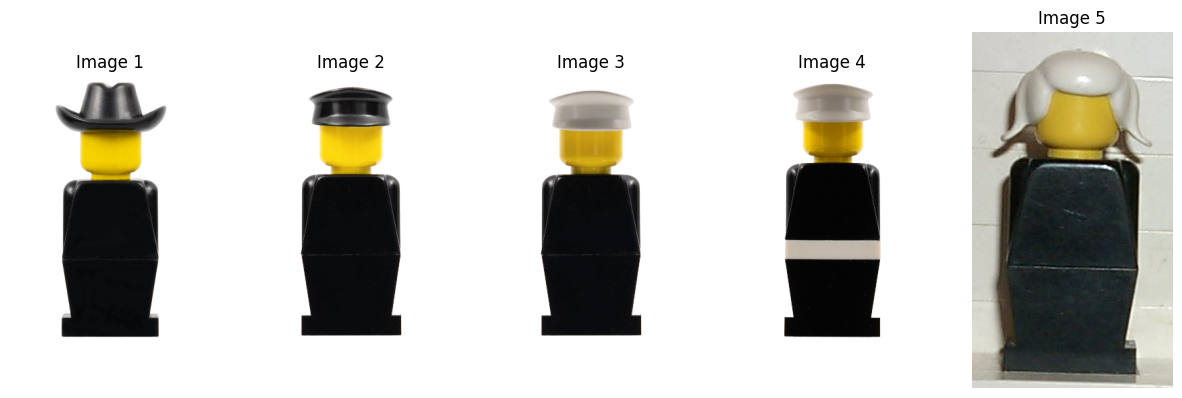


You can continue to load images as needed by calling `next(image_gen)`.


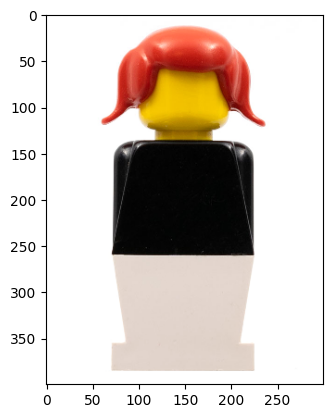

In [ ]:
# Get all local image paths from the DataFrame
all_image_paths = labels['img_local_path'].tolist()

# Create the image generator
image_gen = image_data_loader(all_image_paths)

# Example: Load and display the first 5 images
print("Loading and displaying the first 5 images:")
plt.figure(figsize=(15, 5))
for i in range(5):
    try:
        img = next(image_gen)
        plt.subplot(1, 5, i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # OpenCV reads as BGR, matplotlib expects RGB
        plt.title(f"Image {i+1}")
        plt.axis('off')
    except StopIteration:
        print("No more images to load.")
        break
plt.show()

print("\nYou can continue to load images as needed by calling `next(image_gen)`.")
# For example, to load the 6th image (if it exists):
sixth_image = next(image_gen)
plt.imshow(cv2.cvtColor(sixth_image, cv2.COLOR_BGR2RGB))
plt.show()

Showing the images:
- They have different sizes and different backgrounds \
-> Look at BOAT006.jpg & BOAT007.jpg

In [ ]:
image = cv2.imread("/content/drive/MyDrive/Colab Notebooks/images/4J002.jpg")

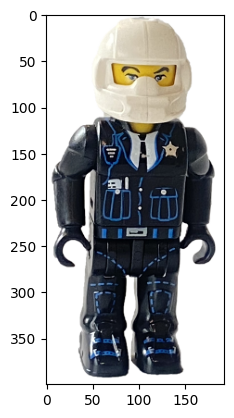

In [ ]:
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

## Preprocessing

- Handling the different image sizes
- Handing the different backgrounds if necesarry
- Handling all the other quirks
  *   There are pictures with multiple lego figures in the same figure (e.g. BOAT006.jpg & BOAT007.jpg -> figure with and without a certain attribute)
  *   There are images with some other views of the figure in it
      + Keeping the other views or not?
- Blurry images (e.g. 47394PB005.jpg & 47394PB006.jpg)
- Why the fuck are some colors being weird, and does this affect potential predictions?
  * Solved ~ish: OpenCV reads as BGR, matplotlib expects RGB


The BOAT files:

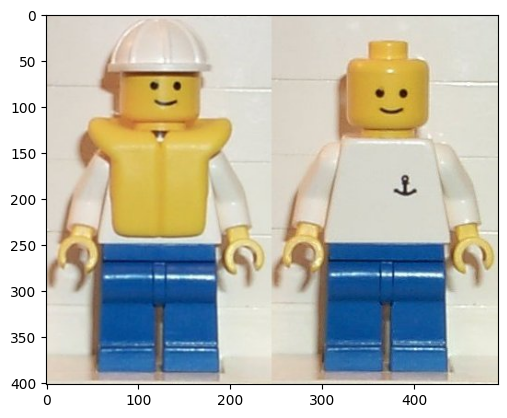

In [ ]:
BOAT006= cv2.imread("/content/drive/MyDrive/Colab Notebooks/images/BOAT006.jpg")
plt.imshow(cv2.cvtColor(BOAT006, cv2.COLOR_BGR2RGB))

In [ ]:
labels[labels["img_local_path"] == "images/BOAT007.jpg"]

,id,name,link,year,img_url,minifig_number,category,subcategory,year_released,set_id,current_value_new,current_value_used,character_name,img_local_path,themes
799,800,"Boat Worker - Torso with Anchor, Blue Legs, Wh...",/minifigs/boat007/boat-worker-torso-with-ancho...,1991,https://img.bricklink.com/ItemImage/MN/0/boat0...,BOAT007,Town,Classic Town / Harbor,1991,1 set,~€1.69,~€1.62,None,images/BOAT007.jpg,[Boats]


## Fitting existing model to our data

We can modify existing models to fit our data.

## Fitting new model to our data

IDK if this is a good idea, might need a lot of tuning to know how many layers and neurons are needed. Let's first see how modifying an existing model goes.

#MULTICLASS


Quick test:

In [ ]:
import tensorflow as tf

# Check if a GPU is available
if tf.test.is_gpu_available():
    print("GPU is available and being used.")
    print("GPU Device Name:", tf.test.gpu_device_name())
else:
    print("No GPU available. TensorFlow is using CPU.")

# Alternatively, list all physical devices (including CPU)
print("\nList of all physical devices:")
print(tf.config.list_physical_devices())

Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.


GPU is available and being used.
GPU Device Name: /device:GPU:0

List of all physical devices:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


 try to predict the category based on the image and if we see that we have too many classes we try only if the top k most frequent categories

We divide the datset in train and validations set

In [ ]:
#to adjust some problems in the running time because it was taking more than 5 hours
import os
import shutil
from tqdm import tqdm

drive_path = '/content/drive/MyDrive/Colab Notebooks/images'
local_dest = '/content/dataset_images'

if not os.path.exists(local_dest):
    os.makedirs(local_dest)

file_list = os.listdir(drive_path)
print(f"Founded {len(file_list)} file. Now copying!")


for file_name in tqdm(file_list, desc="Copying..."):
    src_file = os.path.join(drive_path, file_name)
    dst_file = os.path.join(local_dest, file_name)
    if os.path.isfile(src_file):
      if not os.path.exists(dst_file):
        shutil.copy2(src_file, dst_file)



Founded 17390 file. Now copying!


Copying...: 100%|██████████| 17390/17390 [08:47<00:00, 32.94it/s]


In [ ]:
print("Columns labels name:")
print(labels.columns)

Columns labels name:
Index(['id', 'name', 'link', 'year', 'img_url', 'minifig_number', 'category',
       'subcategory', 'year_released', 'set_id', 'current_value_new',
       'current_value_used', 'character_name', 'img_local_path', 'themes'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

top_10_categories = labels['category'].value_counts().nlargest(10).index
df_filtered = labels[labels['category'].isin(top_10_categories)].copy()
df_filtered = df_filtered.dropna(subset=['img_local_path'])

base_dir='/content/drive/MyDrive/Colab Notebooks/images'

df_filtered['name_file'] = df_filtered['img_local_path'].apply(lambda x: str(x).split('/')[-1])
df_filtered['exist'] = df_filtered['name_file'].apply(lambda x: os.path.exists(os.path.join(base_dir, x)))
df_valid=df_filtered[df_filtered['exist']==True].copy()

df_train, df_temp = train_test_split(df_valid, test_size=0.30, random_state=42, stratify=df_valid['category'])
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=42, stratify=df_temp['category'])

datagen_train = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

datagen_test = ImageDataGenerator(rescale=1./255)

#for the training
train_generator=datagen_train.flow_from_dataframe(
    dataframe=df_train,
    directory=base_dir,
    x_col='name_file',
    y_col='category',
    target_size=(224,224),
    batch_size=128,
    class_mode='categorical'
)

#for the validation
val_generator=datagen_test.flow_from_dataframe(
    dataframe=df_val,
    directory=base_dir,
    x_col='name_file',
    y_col='category',
    target_size=(224,224),
    batch_size=128,
    class_mode='categorical'
)
#for the test
test_generator=datagen_test.flow_from_dataframe(
    dataframe=df_test,
    directory=base_dir,
    x_col='name_file',
    y_col='category',
    target_size=(224,224),
    batch_size=128,
    class_mode='categorical',
    shuffle=False
)

Found 7917 validated image filenames belonging to 10 classes.
Found 1697 validated image filenames belonging to 10 classes.
Found 1697 validated image filenames belonging to 10 classes.


We try to construct the model with transfer learning

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D,Dropout

In [ ]:
base_model=MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable=False
x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dropout(0.5)(x)
predictions=Dense(10, activation='softmax')(x)
model=Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Now we train the model:

In [ ]:
history=model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.4367 - loss: 1.8462 - val_accuracy: 0.6553 - val_loss: 1.0692
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.6211 - loss: 1.1760 - val_accuracy: 0.7089 - val_loss: 0.9024
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6710 - loss: 1.0238 - val_accuracy: 0.7183 - val_loss: 0.8156
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.6948 - loss: 0.9253 - val_accuracy: 0.7336 - val_loss: 0.7787
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.7094 - loss: 0.8827 - val_accuracy: 0.7519 - val_loss: 0.7428


CAVEAT: a little bit slow around 10 minutes of run time

In [ ]:
test_loss,test_accuracy=model.evaluate(test_generator)
print(f'Test accuracy: {test_accuracy}')

14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 760ms/step - accuracy: 0.7637 - loss: 0.7429
Test accuracy: 0.7637006640434265


#SOME PLOTS

In [ ]:
import matplotlib.pyplot as plt
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1, len(acc)+1)
plt.figure(figsize=(12,5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

accuracy plot

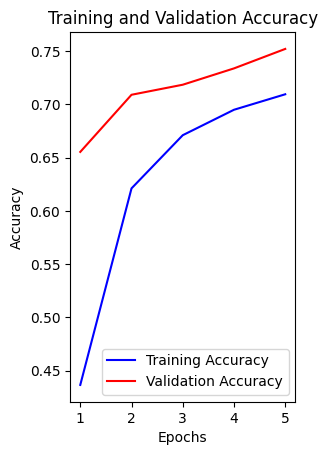

In [ ]:
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

The training accuracy keeps increasing, with the validation accuracy we arrive to 78% precision which is good since we are considering only 5 epochs

Loss Graph

In [ ]:
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

NameError: name 'plt' is not defined

We want a low loss because in this way the model is more precise. The training loss line keeps decreasing. For the red one we can see that it decreases and then decreases again->overfitting-> after the third epochs the model starts struggling->it was a good choice to use data augmentation and dropout

#Prediction on a couple of test images

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

We take 32 images from the validations et

In [ ]:
x_batch, y_batch=next(test_generator)

We try to predict to which category they are part

In [ ]:
prediction=model.predict(x_batch)

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step


In [ ]:
name_classes=list(train_generator.class_indices.keys())

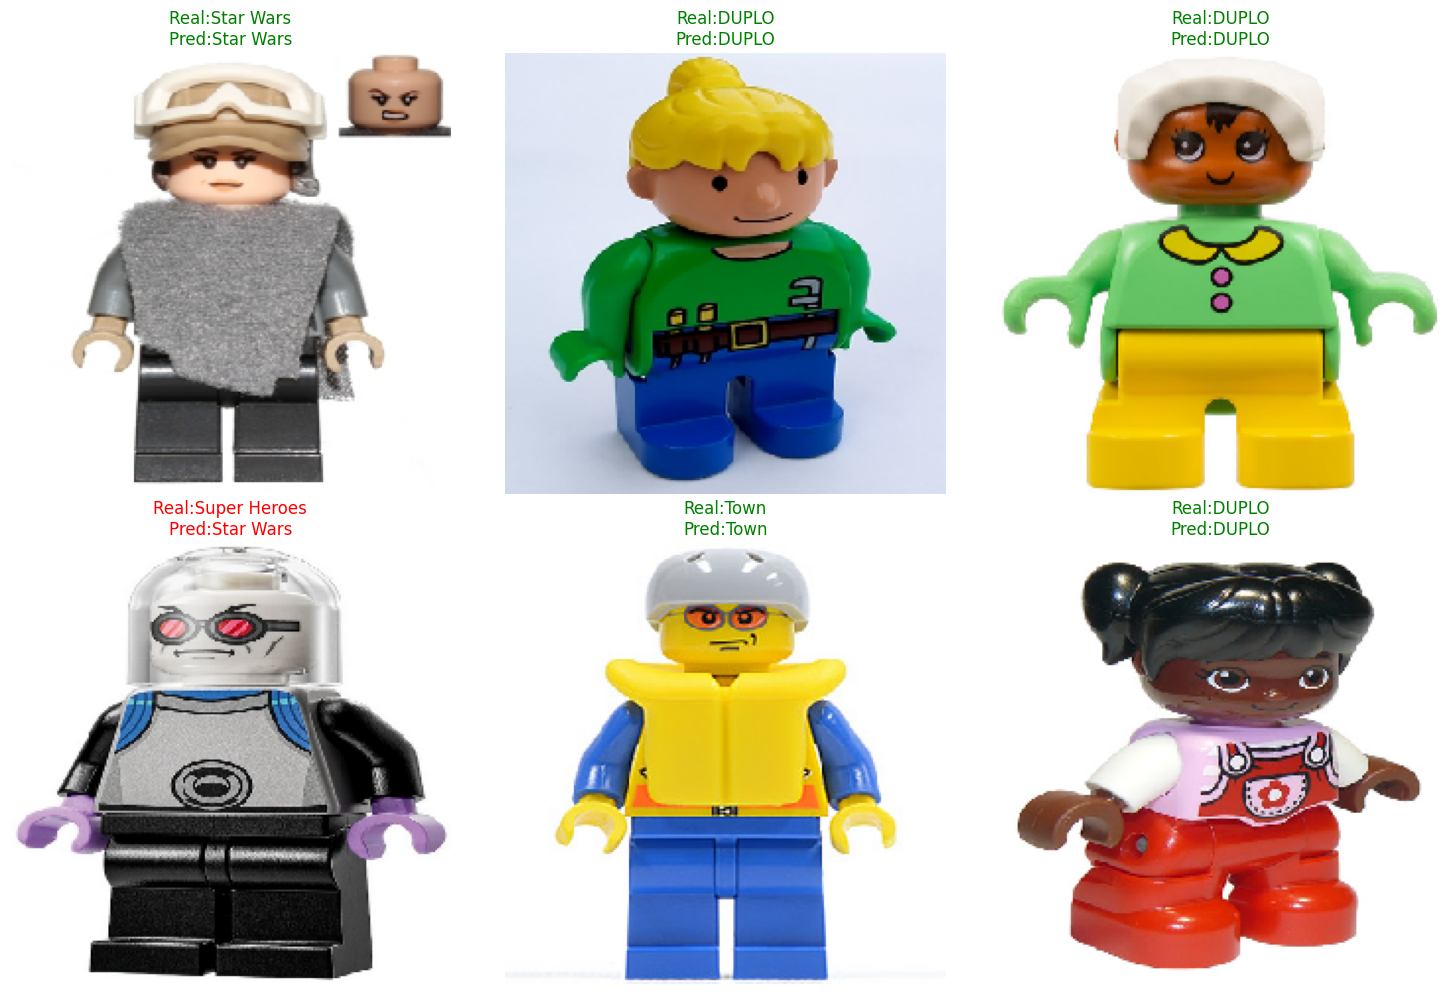

In [ ]:
plt.figure(figsize=(15,10))
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(x_batch[i])
  real_index=np.argmax(y_batch[i])
  pred_index=np.argmax(prediction[i])
  real_class=name_classes[real_index]
  pred_class=name_classes[pred_index]
  color='green' if real_index==pred_index else 'red'
  plt.title(f'Real:{real_class}\nPred:{pred_class}', color=color)
  plt.axis('off')


plt.tight_layout()
plt.show()

The model was able to predict 5 out of 6 legos->the model might have predicted in the wrong way the super hero character because it resemble a character from star wars

Now we try to improve it to see if we are able to predict 6 out of 6 characters and increase the accuracy

In [ ]:
from tensorflow.keras.optimizers import  Adam
base_model.trainable=True
for layer in base_model.layers[:100]:
  layer.trainable=False
model.compile(
    optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history_fineture  =model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator
)

Epoch 1/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.7029 - loss: 0.9262 - val_accuracy: 0.7437 - val_loss: 0.8470
Epoch 2/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.8210 - loss: 0.5446 - val_accuracy: 0.7643 - val_loss: 0.7826
Epoch 3/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.8659 - loss: 0.4089 - val_accuracy: 0.7336 - val_loss: 0.8735
Epoch 4/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.8953 - loss: 0.3264 - val_accuracy: 0.7808 - val_loss: 0.7414
Epoch 5/5
62/62 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.9151 - loss: 0.2564 - val_accuracy: 0.7814 - val_loss: 0.7440


In [ ]:
import matplotlib.pyplot as plt
acc=history_fineture.history['accuracy']
val_acc=history_fineture.history['val_accuracy']
loss=history_fineture.history['loss']
val_loss=history_fineture.history['val_loss']
epochs=range(1, len(acc)+1)
plt.figure(figsize=(12,5))


<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

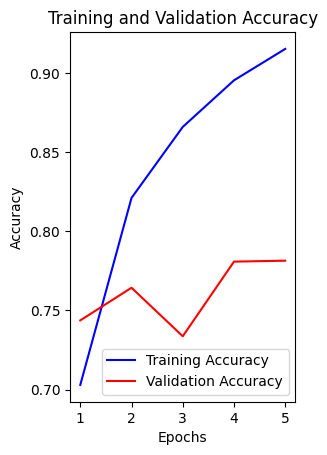

In [ ]:
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

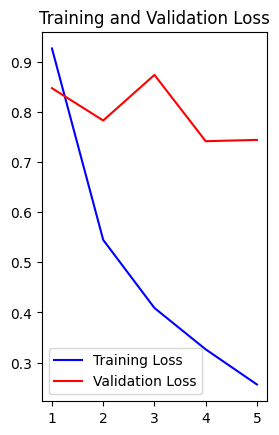

In [ ]:
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [ ]:
final_loss, final_acc=model.evaluate(test_generator)
print(f'accuracy: {final_acc * 100:.2f}%')

14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 715ms/step - accuracy: 0.7666 - loss: 0.8080
accuracy: 76.66%


In [ ]:
x_batch, y_batch=next(test_generator)


In [ ]:
prediction=model.predict(x_batch)


4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step


In [ ]:
name_classes=list(train_generator.class_indices.keys())


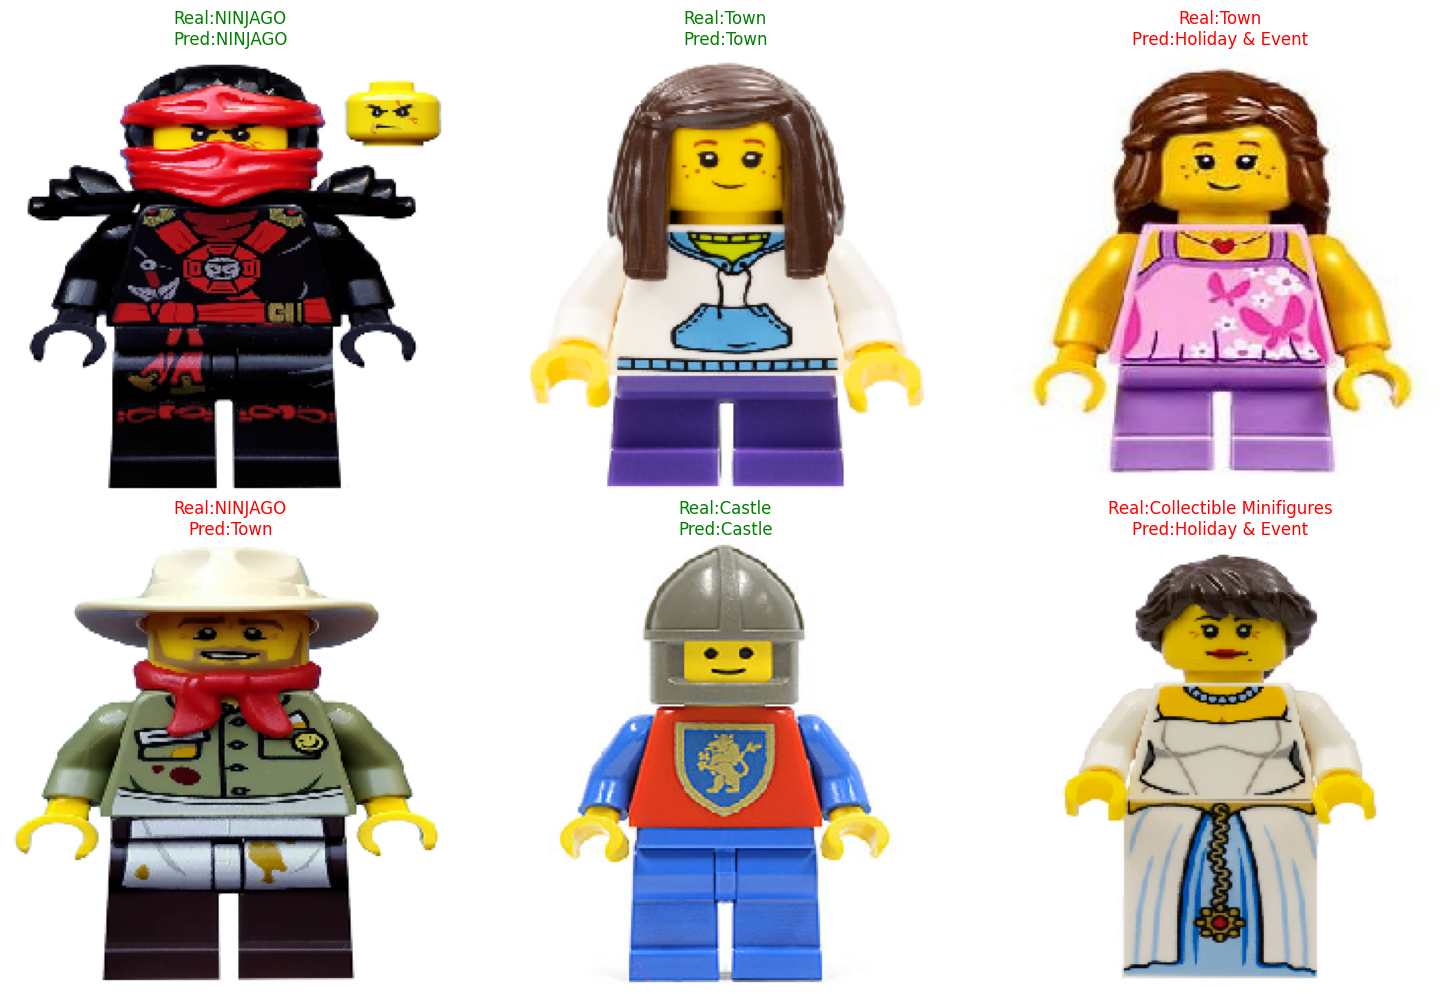

In [ ]:
plt.figure(figsize=(15,10))
for i in range(6):
  plt.subplot(2,3,i+1)
  plt.imshow(x_batch[i])
  real_index=np.argmax(y_batch[i])
  pred_index=np.argmax(prediction[i])
  real_class=name_classes[real_index]
  pred_class=name_classes[pred_index]
  color='green' if real_index==pred_index else 'red'
  plt.title(f'Real:{real_class}\nPred:{pred_class}', color=color)
  plt.axis('off')


plt.tight_layout()
plt.show()

These results are a proof of the overfitting infact:
-training line arrives to a very high accuracy(close to 95%)
-the validation line goes up and down arriving at 70%(value similar to the previous case)
->the model has studied 'by heart' the various characteristics and is not able anymore to generalize
It got  4 out of 6 good predictions:
-starwars character: they look different from the classic lego with bigger head and different bodies so he put it in a random category
->WE GOT OVERFITTING

#INTERPRETABILITY

we try to apply Grad CAM algorithm

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


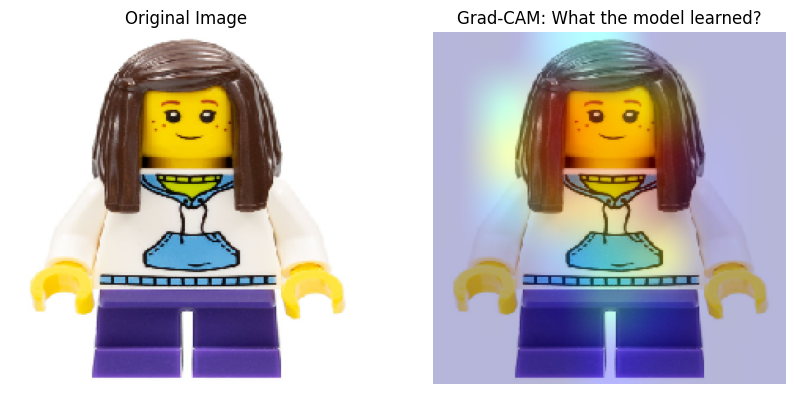

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="out_relu"):
    inner_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            inner_model = layer
            break

    if inner_model is not None:
        last_conv_layer = inner_model.get_layer(last_conv_layer_name)
        conv_model = tf.keras.Model(inner_model.inputs, last_conv_layer.output)
        classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
        x = classifier_input
        start_idx = model.layers.index(inner_model) + 1
        for layer in model.layers[start_idx:]:
            x = layer(x)
        classifier_model = tf.keras.Model(classifier_input, x)
    else:
        last_conv_layer = model.get_layer(last_conv_layer_name)
        conv_model = tf.keras.Model(model.inputs, last_conv_layer.output)
        classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
        x = classifier_input
        start_idx = model.layers.index(last_conv_layer) + 1
        for layer in model.layers[start_idx:]:
            x = layer(x)
        classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)
        preds = classifier_model(conv_outputs)
        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ tf.expand_dims(pooled_grads, axis=-1)
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

index = 1
img = x_batch[index]
img_array = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(img_array, model)

heatmap_resized = np.uint8(255 * heatmap)
jet = cm.jet
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_resized]

img_original = np.uint8(255 * img)
jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img_original.shape[1], img_original.shape[0]))
jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

superimposed_img = jet_heatmap * 0.4 + img_original
superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM: What the model learned?")
plt.axis('off')

plt.show()

we try with  a random one (if you want you can just change the number in index to see how kit behaves with different ones)

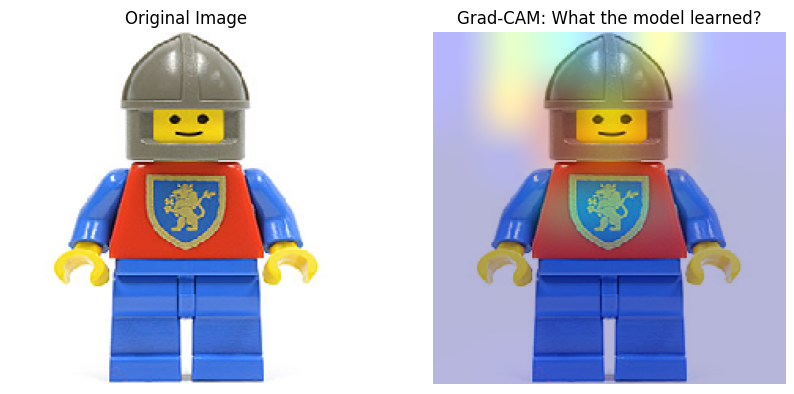

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="out_relu"):
    inner_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            inner_model = layer
            break

    if inner_model is not None:
        last_conv_layer = inner_model.get_layer(last_conv_layer_name)
        conv_model = tf.keras.Model(inner_model.inputs, last_conv_layer.output)
        classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
        x = classifier_input
        start_idx = model.layers.index(inner_model) + 1
        for layer in model.layers[start_idx:]:
            x = layer(x)
        classifier_model = tf.keras.Model(classifier_input, x)
    else:
        last_conv_layer = model.get_layer(last_conv_layer_name)
        conv_model = tf.keras.Model(model.inputs, last_conv_layer.output)
        classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
        x = classifier_input
        start_idx = model.layers.index(last_conv_layer) + 1
        for layer in model.layers[start_idx:]:
            x = layer(x)
        classifier_model = tf.keras.Model(classifier_input, x)

    with tf.GradientTape() as tape:
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)
        preds = classifier_model(conv_outputs)
        top_pred_index = tf.argmax(preds[0])
        top_class_channel = preds[:, top_pred_index]

    grads = tape.gradient(top_class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ tf.expand_dims(pooled_grads, axis=-1)
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

index = 4
img = x_batch[index]
img_array = np.expand_dims(img, axis=0)

heatmap = make_gradcam_heatmap(img_array, model)

heatmap_resized = np.uint8(255 * heatmap)
jet = cm.jet
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_resized]

img_original = np.uint8(255 * img)
jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img_original.shape[1], img_original.shape[0]))
jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)

superimposed_img = jet_heatmap * 0.4 + img_original
superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM: What the model learned?")
plt.axis('off')

plt.show()

---------------------Below is Ming's version----------------------

With category=20; EfficientNetB0 mode

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Here maybe you need change the path, it's exactly the **zip** file the teacher gives up on toledo


In [ ]:
import zipfile, os

zip_path = '/content/drive/MyDrive/lego/images.zip'
extract_to = '/content/'

print("Extracting, please wait (approx. 1-2 minutes)...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_to)

print(f"Extraction complete! Number of images: {len(os.listdir('/content/images'))}")

Extracting, please wait (approx. 1-2 minutes)...


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/lego/images.zip'

In [ ]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
import keras
from keras import layers, Model, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score

warnings.filterwarnings('ignore')
print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU: {gpus[0].name if gpus else "Not detected"}')

TensorFlow : 2.19.0
Keras      : 3.13.2
GPU: /physical_device:GPU:0


In [ ]:
with open(JSON_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(f'Total entries: {len(df)}')

cat_counts = df['category'].value_counts()
print(f'Total categories: {len(cat_counts)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
cat_counts.head(20).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 20 Categories')
axes[0].tick_params(axis='x', rotation=45)
axes[1].hist(cat_counts.values, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Samples per Category')
plt.tight_layout(); plt.show()

NameError: name 'JSON_PATH' is not defined

KeyError: 'img_full_path'

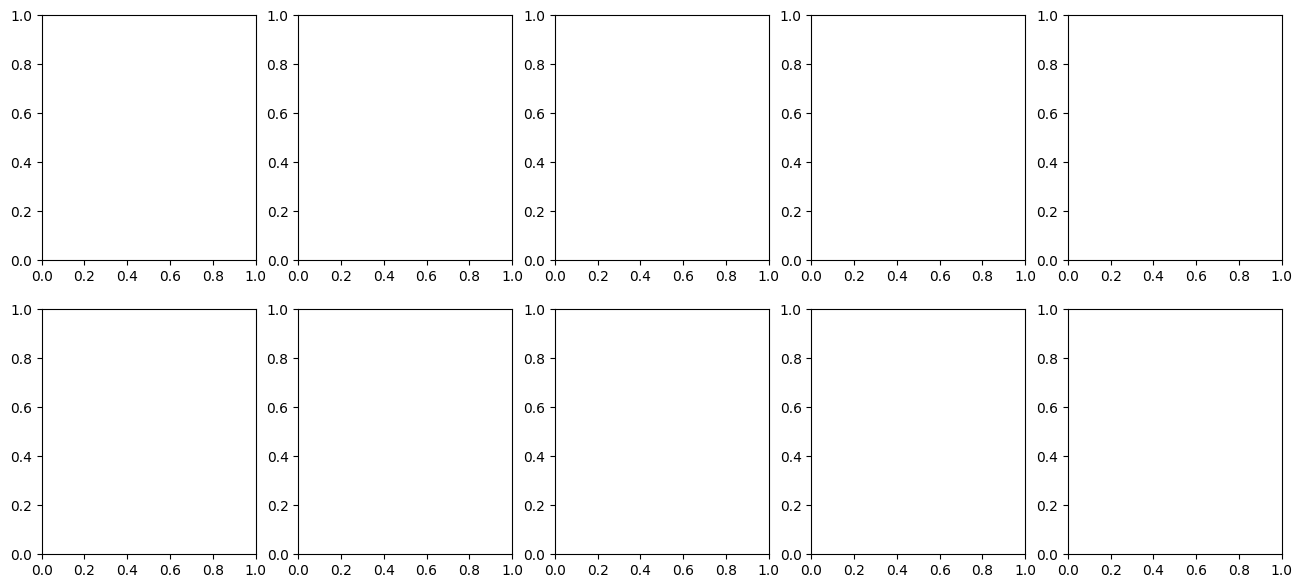

In [ ]:
sample = df_filtered.drop_duplicates(subset='category').head(10).reset_index(drop=True)
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = cv2.imread(row['img_full_path'], cv2.IMREAD_UNCHANGED)
    if img is None:
        ax.axis('off'); continue
    if len(img.shape) == 3 and img.shape[2] == 4:
        bgr = img[:,:,:3]; alpha = img[:,:,3:]/255.0
        white = np.ones_like(bgr, dtype=np.uint8)*255
        img = (bgr*alpha + white*(1-alpha)).astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img); ax.set_title(row['category'], fontsize=8); ax.axis('off')
plt.suptitle('Sample images (one per category)')
plt.tight_layout(); plt.show()

In [ ]:
le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['category'])
NUM_CLASSES = len(le.classes_)
print(f'Number of classes: {NUM_CLASSES}')
print(le.classes_.tolist())

df_train, df_test = train_test_split(
    df_filtered, test_size=0.10,
    stratify=df_filtered['label'], random_state=SEED
)
df_train, df_val = train_test_split(
    df_train, test_size=0.111,
    stratify=df_train['label'], random_state=SEED
)
print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}')

In [ ]:
augment_layer = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomBrightness(0.10),
    layers.RandomContrast(0.10),
], name='augmentation')

def load_image(img_path, label):
    raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(df_split, augment=False, shuffle=False):
    paths  = df_split['img_full_path'].tolist()
    labels = df_split['label'].tolist()
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=2000, seed=SEED)
    if augment:
        ds = ds.map(
            lambda x, y: (augment_layer(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(df_train, augment=True,  shuffle=True)
val_ds   = make_dataset(df_val,   augment=False, shuffle=False)
test_ds  = make_dataset(df_test,  augment=False, shuffle=False)
print('Datasets ready ✅')

In [ ]:
def build_model(num_classes, freeze_base=True):
    base = EfficientNetB0(
        include_top=False, weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base.trainable = not freeze_base

    inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.L2(1e-4))(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = build_model(NUM_CLASSES, freeze_base=True)
model.summary()

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=6,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('/content/drive/MyDrive/lego/best_model.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]

print('Stage 1: Training head only (backbone frozen)')
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history1 = model.fit(train_ds, validation_data=val_ds,
                     epochs=20, callbacks=callbacks)

In [ ]:
print('Stage 2: Fine-tuning full network')
model.layers[1].trainable = True
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history2 = model.fit(train_ds, validation_data=val_ds,
                     epochs=40, callbacks=callbacks)

In [ ]:
print('Stage 2: Fine-tuning full network')
model.layers[1].trainable = True
# Freeze the first 100 layers of EfficientNet, only fine-tune the later layers
for layer in model.layers[1].layers[:100]:
    layer.trainable = False
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history2 = model.fit(train_ds, validation_data=val_ds,
                     epochs=40, callbacks=callbacks)

In [ ]:
model = keras.models.load_model('/content/drive/MyDrive/lego/best_model.keras')

y_true, y_pred_probs = [], []
for imgs, labels in test_ds:
    probs = model.predict(imgs, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(probs)

y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

print(f'Test Accuracy : {np.mean(y_true==y_pred):.4f}')
print(f'Macro F1      : {f1_score(y_true, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14,12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

In [ ]:
LAST_CONV = 'top_conv'

def make_gradcam_heatmap(img_array, model):
    efficientnet = model.get_layer('efficientnetb0')
    conv_model = keras.Model(
        inputs=efficientnet.input,
        outputs=efficientnet.get_layer('top_conv').output
    )

    # Step 1: Get the conv output
    conv_out = conv_model(img_array, training=False)
    conv_out_var = tf.Variable(conv_out)

    # Step 2: Calculate gradients from the conv output
    with tf.GradientTape() as tape:
        tape.watch(conv_out_var)
        # Manually perform GAP + subsequent layers
        x = tf.reduce_mean(conv_out_var, axis=[1, 2])  # GAP
        # Run the full model to get predictions
        preds = model(img_array, training=False)
        top_class = int(tf.argmax(preds[0]))
        class_score = preds[0, top_class]

    grads = tape.gradient(class_score, conv_out_var)

    if grads is None:
        # Fallback: Use the mean of conv_out directly as heatmap
        heatmap = tf.reduce_mean(conv_out[0], axis=-1)
    else:
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

    heatmap = tf.nn.relu(heatmap)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_path, heatmap, alpha=0.45):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    hm  = cv2.resize(heatmap, (IMG_SIZE, IMG_SIZE))
    hm_color = cv2.applyColorMap(np.uint8(255*hm), cv2.COLORMAP_JET)
    hm_color = cv2.cvtColor(hm_color, cv2.COLOR_BGR2RGB)
    return img, cv2.addWeighted(img, 1-alpha, hm_color, alpha, 0)

N = 6
sample = df_test.sample(N, random_state=SEED).reset_index(drop=True)
fig, axes = plt.subplots(N, 3, figsize=(12, N*3.5))
for col, title in enumerate(['Original', 'GradCAM Overlay', 'Top-5 Confidence']):
    axes[0, col].set_title(title, fontweight='bold')

for i, (_, row) in enumerate(sample.iterrows()):
    path = row['img_full_path']
    raw  = tf.io.read_file(path)
    img_t = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img_t = tf.image.resize(img_t, [IMG_SIZE, IMG_SIZE])
    img_arr = tf.cast(img_t, tf.float32)[tf.newaxis] / 255.0

    preds      = model.predict(img_arr, verbose=0)[0]
    pred_label = le.classes_[np.argmax(preds)]
    true_label = row['category']
    correct    = '✅' if pred_label == true_label else '❌'

    heatmap           = make_gradcam_heatmap(img_arr, model)
    original, overlay = overlay_gradcam(path, heatmap)

    axes[i,0].imshow(original)
    axes[i,0].set_ylabel(f'True: {true_label}', fontsize=9)
    axes[i,0].axis('off')
    axes[i,1].imshow(overlay)
    axes[i,1].set_ylabel(f'Pred: {pred_label} {correct}', fontsize=9)
    axes[i,1].axis('off')

    top5_idx  = np.argsort(preds)[::-1][:5]
    top5_lbls = [le.classes_[j] for j in top5_idx]
    top5_vals = preds[top5_idx]
    colors    = ['green' if l==true_label else 'steelblue' for l in top5_lbls]
    axes[i,2].barh(top5_lbls[::-1], top5_vals[::-1], color=colors[::-1])
    axes[i,2].set_xlim(0,1)
    axes[i,2].set_xlabel('Confidence')

plt.suptitle('GradCAM Interpretability — Test Images', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/lego/gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to Google Drive ✅')